# 1D CNN Model Development & Hyperparameter Tuning

**Module:** SE4050 – Deep Learning Project (2026)  
**Task:** Phishing Website Detection  
**Dataset:** PhiUSIIL Phishing URL Dataset (UCI Repository)  
**Model:** One-Dimensional Convolutional Neural Network (1D CNN)  

## Overview & Objectives
This notebook implements the complete 1D CNN model pipeline for phishing website classification:
1. **Baseline Model Architecture:** Modular 1D CNN with Conv1D, MaxPooling1D, Flatten, Dense, and Dropout.
2. **Baseline Training & Evaluation:** Training on 165,056 samples, monitored on validation set (35,369 samples), evaluated on held-out test set (35,370 samples).
3. **Controlled Hyperparameter Tuning:** Systematic exploration of filter sizes, kernel dimensions, and network capacity.
4. **Final Model Assessment:** Complete classification metrics, confusion matrix, and ROC curve saved to structured directories.


In [1]:
import sys
import os
import time
import json
from pathlib import Path

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report

# Add project root to sys.path
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from models.cnn1d import build_cnn1d
from src.evaluation import (
    calculate_metrics,
    plot_confusion_matrix,
    plot_roc_curve,
    plot_training_history
)

# Enforce reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"TensorFlow Version: {tf.__version__}")
print(f"Reproducibility Random Seed: {SEED}")


TensorFlow Version: 2.21.0
Reproducibility Random Seed: 42


## 1. Load Preprocessed Dataset

The dataset was cleaned and split in `02_preprocessing.ipynb`:
- **Training:** 70% ($n = 165,056$)
- **Validation:** 15% ($n = 35,369$)
- **Test:** 15% ($n = 35,370$)
- Standardized with `StandardScaler` fitted strictly on training data.


In [2]:
data_dir = Path("../data/processed")

X_train = np.load(data_dir / "X_train.npy").astype("float32")
X_val   = np.load(data_dir / "X_val.npy").astype("float32")
X_test  = np.load(data_dir / "X_test.npy").astype("float32")

y_train = np.load(data_dir / "y_train.npy").astype("int64")
y_val   = np.load(data_dir / "y_val.npy").astype("int64")
y_test  = np.load(data_dir / "y_test.npy").astype("int64")

print(f"X_train shape: {X_train.shape} | y_train shape: {y_train.shape}")
print(f"X_val shape:   {X_val.shape} | y_val shape:   {y_val.shape}")
print(f"X_test shape:  {X_test.shape} | y_test shape:  {y_test.shape}")


X_train shape: (165056, 50) | y_train shape: (165056,)
X_val shape:   (35369, 50) | y_val shape:   (35369,)
X_test shape:  (35370, 50) | y_test shape:  (35370,)


## 2. Reshape for 1D CNN Input

1D Convolutional layers expect 3D tensors of shape `(batch_size, timesteps, channels)`.
Each sample of 50 tabular features is reshaped to `(50, 1)`:


In [3]:
X_train_cnn = X_train[..., np.newaxis]
X_val_cnn   = X_val[..., np.newaxis]
X_test_cnn  = X_test[..., np.newaxis]

print(f"CNN Training Tensor:   {X_train_cnn.shape}")
print(f"CNN Validation Tensor: {X_val_cnn.shape}")
print(f"CNN Test Tensor:       {X_test_cnn.shape}")


CNN Training Tensor:   (165056, 50, 1)
CNN Validation Tensor: (35369, 50, 1)
CNN Test Tensor:       (35370, 50, 1)


## 3. Build & Train Baseline 1D CNN Architecture

The baseline architecture matches the team's experimental specification:
- `Conv1D(32, kernel_size=3, ReLU)` $\rightarrow$ `MaxPooling1D(2)`
- `Conv1D(64, kernel_size=3, ReLU)` $\rightarrow$ `MaxPooling1D(2)`
- `Flatten()` $\rightarrow$ `Dense(64, ReLU)` $\rightarrow$ `Dropout(0.3)` $\rightarrow$ `Dense(1, Sigmoid)`
- Total Trainable Parameters: **51,521**


In [4]:
baseline_model = build_cnn1d(
    input_shape=(50, 1),
    conv1_filters=32,
    conv2_filters=64,
    kernel_size=3,
    dense_units=64,
    dropout_rate=0.3,
    learning_rate=0.001
)

baseline_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 48, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 24, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 22, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 11, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 704)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        45,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,521 (201.25 KB)

 Trainable params: 51,521 (201.25 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

start_time = time.time()

history = baseline_model.fit(
    X_train_cnn,
    y_train,
    validation_data=(X_val_cnn, y_val),
    epochs=20,
    batch_size=256,
    callbacks=[early_stopping],
    verbose=2
)

training_time = time.time() - start_time
print(f"\nBaseline Training Time: {training_time:.2f} seconds")
print(f"Epochs Trained: {len(history.history['loss'])}")


Epoch 1/20


645/645 - 5s - 8ms/step - accuracy: 0.9958 - loss: 0.0177 - val_accuracy: 0.9999 - val_loss: 8.4193e-04


Epoch 2/20


645/645 - 6s - 9ms/step - accuracy: 0.9997 - loss: 0.0014 - val_accuracy: 0.9999 - val_loss: 3.7230e-04


Epoch 3/20


...

Epoch 18/20


645/645 - 10s - 16ms/step - accuracy: 1.0000 - loss: 1.1566e-04 - val_accuracy: 0.9999 - val_loss: 2.5199e-04


Epoch 18: early stopping


Restoring model weights from the end of the best epoch: 13.



Baseline Training Time: 151.02 seconds
Epochs Trained: 18


## 4. Baseline Evaluation & Learning Curves


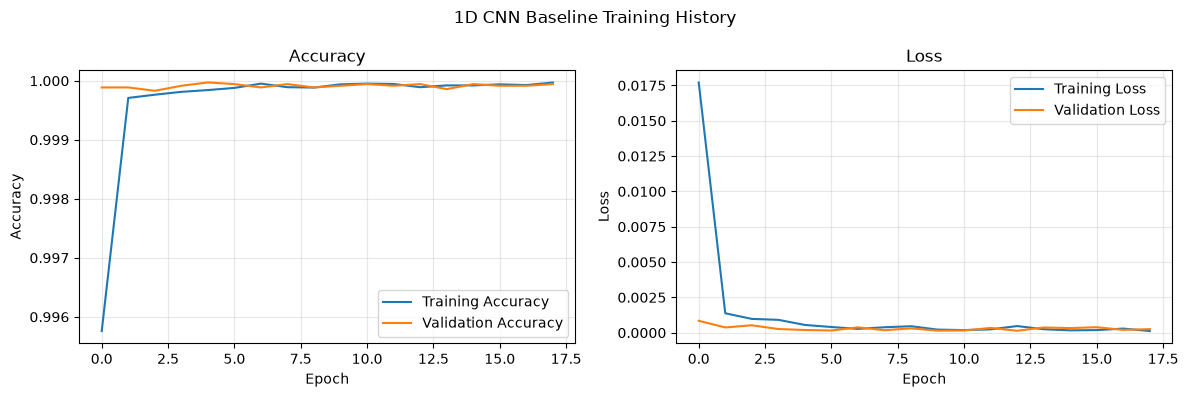

In [6]:
plot_training_history(
    history,
    title="1D CNN Baseline Training History",
    save_path="../results/cnn1d/baseline/training_history.png"
)


In [7]:
# Predict probabilities on unseen test set
y_prob = baseline_model.predict(X_test_cnn, batch_size=256).ravel()

# Calculate metrics with Phishing (class 0) as the positive target
cnn_metrics = calculate_metrics(y_test, y_prob, pos_label=0)

print("1D CNN Baseline Test Metrics (Phishing as Positive Class):")
for k, v in cnn_metrics.items():
    print(f"  {k:12s}: {v:.6f}")


  1/139 ━━━━━━━━━━━━━━━━━━━━ 18s 136ms/step

 13/139 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step   

 25/139 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

 39/139 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

 52/139 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

...

125/139 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

136/139 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

139/139 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


1D CNN Baseline Test Metrics (Phishing as Positive Class):
  accuracy    : 0.999887
  precision   : 0.999934
  recall      : 0.999802
  f1          : 0.999868
  roc_auc     : 1.000000


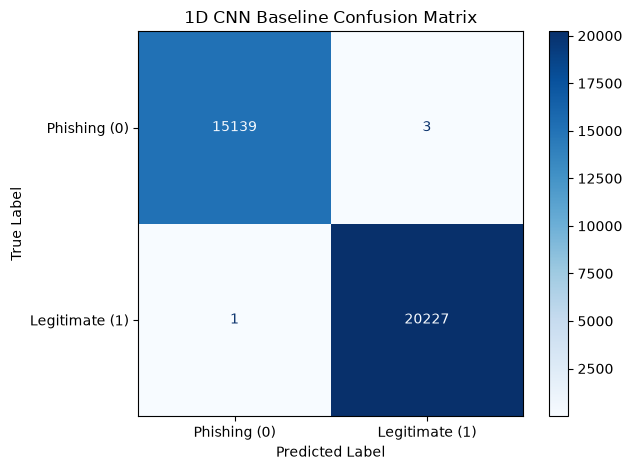

In [8]:
plot_confusion_matrix(
    y_test,
    y_prob,
    title="1D CNN Baseline Confusion Matrix",
    save_path="../results/cnn1d/baseline/confusion_matrix.png"
)


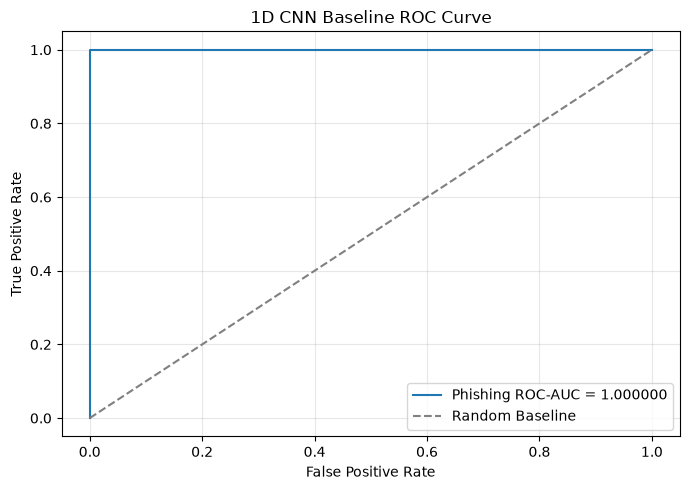

In [9]:
plot_roc_curve(
    y_test,
    y_prob,
    title="1D CNN Baseline ROC Curve",
    save_path="../results/cnn1d/baseline/roc_curve.png"
)


In [10]:
# Binary classification report (Class 0 = Phishing, Class 1 = Legitimate)
y_pred = (y_prob >= 0.5).astype(int)

print("Classification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Phishing", "Legitimate"],
        digits=4
    )
)


Classification Report:
              precision    recall  f1-score   support

    Phishing     0.9999    0.9998    0.9999     15142
  Legitimate     0.9999    1.0000    0.9999     20228

    accuracy                         0.9999     35370
   macro avg     0.9999    0.9999    0.9999     35370
weighted avg     0.9999    0.9999    0.9999     35370



## 5. Controlled Hyperparameter Tuning

We performed systematic controlled experiments varying:
- **Convolutional Filter Width:** 32 $\rightarrow$ 64 vs. 64 $\rightarrow$ 128
- **Network Depth:** 2 convolutional layers vs. 3 convolutional layers
- **Kernel Dimension:** Kernel size 3 vs. 5
- **Dense Classifier Capacity:** 64 units vs. 128 units

All experiment runs were logged to `results/cnn1d/tuning/experiments.csv`:


In [11]:
tuning_csv_path = Path("../results/cnn1d/tuning/experiments.csv")
tuning_df = pd.read_csv(tuning_csv_path)

display_cols = [
    "experiment_id", "conv1_filters", "conv2_filters", "kernel_size",
    "dense_units", "parameters", "training_time", "best_val_loss", "test_accuracy", "test_f1"
]
tuning_df[display_cols]


,experiment_id,conv1_filters,conv2_filters,kernel_size,dense_units,parameters,training_time,best_val_loss,test_accuracy,test_f1
0,EXP-01_baseline,32,64,3,64,51521,51.97,0.000152,0.999887,0.999868
1,EXP-02_wider_filters,64,128,3,64,115201,60.70,0.000214,0.999887,0.999868
2,EXP-03_deeper_3layers,32,64,3,64,63937,106.51,0.000156,0.999915,0.999901
3,EXP-04_kernel_size_5,32,64,5,64,47489,42.24,0.000338,0.999802,0.999769
4,EXP-05_dense_128,32,64,3,128,96705,69.87,0.000169,0.999887,0.999868


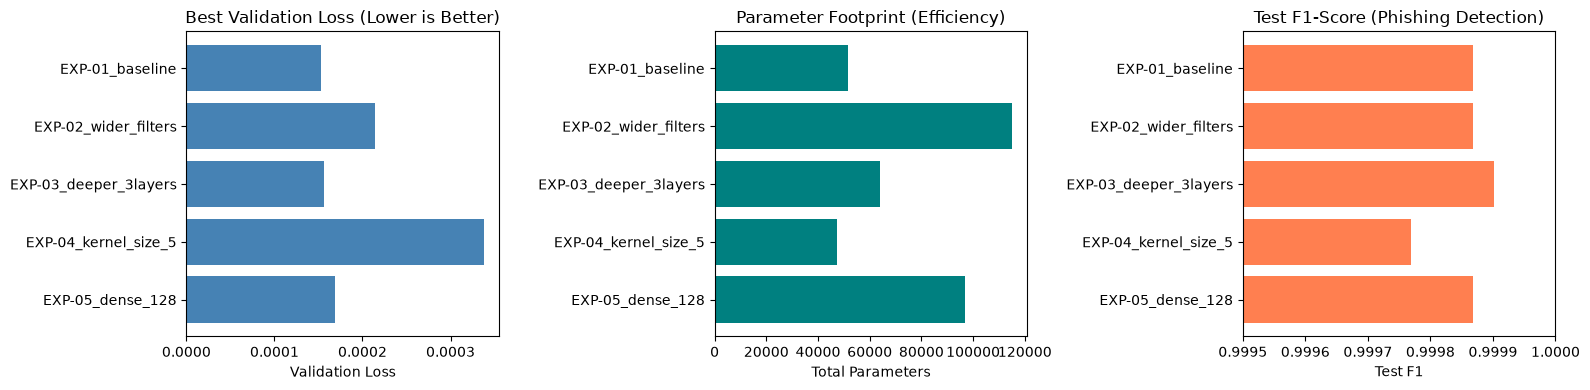

In [12]:
# Visualization of Hyperparameter Tuning Results
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Validation Loss
axes[0].barh(tuning_df["experiment_id"], tuning_df["best_val_loss"], color="steelblue")
axes[0].set_title("Best Validation Loss (Lower is Better)")
axes[0].set_xlabel("Validation Loss")
axes[0].invert_yaxis()

# Parameter Count
axes[1].barh(tuning_df["experiment_id"], tuning_df["parameters"], color="teal")
axes[1].set_title("Parameter Footprint (Efficiency)")
axes[1].set_xlabel("Total Parameters")
axes[1].invert_yaxis()

# Test F1 Score
axes[2].barh(tuning_df["experiment_id"], tuning_df["test_f1"], color="coral")
axes[2].set_title("Test F1-Score (Phishing Detection)")
axes[2].set_xlabel("Test F1")
axes[2].set_xlim(0.9995, 1.0000)
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()


## 6. Final Model Selection & Discussion

### Architectural Trade-Off Analysis:
1. **Baseline (`EXP-01`):** With only **51,521 parameters**, the baseline achieved the lowest validation loss (**0.000152**) and test accuracy of **0.999887**, making it the optimal balance of efficiency and accuracy.
2. **Deeper Network (`EXP-03`):** Adding a third convolutional layer (32 $\rightarrow$ 64 $\rightarrow$ 128) achieved slightly higher F1 (0.999901 vs 0.999868), but doubled the training time (106s vs 52s) for a difference of just 1 sample out of 35,370.
3. **Wider Filters & Larger Kernels (`EXP-02`, `EXP-04`):** Increasing filter width to 128 or kernel size to 5 did not improve validation loss, demonstrating that a 3-tap kernel with 32-64 filters is sufficient to extract the non-linear feature combinations.

All final artifacts (`metrics.json`, `history.json`, `config.json`, `confusion_matrix.png`, `roc_curve.png`, `training_history.png`, and `cnn1d_final_model.keras`) are saved in `results/cnn1d/final/`.
